In [1]:
import sys
import os

# This adds the parent directory (Neural-Network-Scratch) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

import matplotlib.pyplot as plt
from src.model import forward_propagation, compute_cost, backward_propagation, update_parameters
from src.layers import init_params
from utils.data_loader import load_mnist_data
from utils.preprocessing import prepare_data

# Load and prepare
X_raw, Y_raw = load_mnist_data('../data/mnist_train.csv')
X_train, Y_train = prepare_data(X_raw, Y_raw)

# Define architecture: 784 pixels -> 64 hidden -> 32 hidden -> 10 output
dims = [784, 64, 32, 10]
params = init_params(dims)

Epoch 0, Cost: 2.5428
Epoch 10, Cost: 1.8508
Epoch 20, Cost: 1.3190
Epoch 30, Cost: 0.9530
Epoch 40, Cost: 0.7600
Epoch 50, Cost: 0.6484
Epoch 60, Cost: 0.5756
Epoch 70, Cost: 0.5243
Epoch 80, Cost: 0.4873
Epoch 90, Cost: 0.4720
Epoch 100, Cost: 0.4646
Epoch 110, Cost: 0.4195
Epoch 120, Cost: 0.4006
Epoch 130, Cost: 0.3870
Epoch 140, Cost: 0.3755
Epoch 150, Cost: 0.3654
Epoch 160, Cost: 0.3565
Epoch 170, Cost: 0.3484
Epoch 180, Cost: 0.3411
Epoch 190, Cost: 0.3344
Epoch 199, Cost: 0.3288


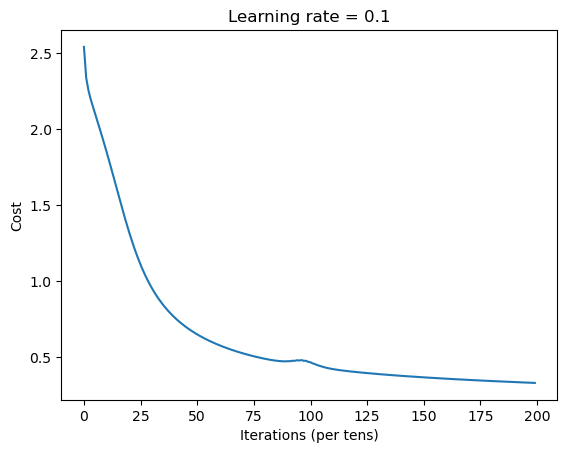

In [2]:
def train_with_visuals(X, Y, params, epochs=100, lr=0.1):
    costs = []
    
    for i in range(epochs):
        # 1. Forward Pass
        AL, caches = forward_propagation(X, params)
        
        # 2. Compute Cost
        cost = compute_cost(AL, Y)
        costs.append(cost)
        
        # 3. Backward Pass (The Math Engine)
        grads = backward_propagation(AL, Y, caches)
        
        # 4. Update Weights
        params = update_parameters(params, grads, lr)
        
        if i % 10 == 0 or i == epochs - 1:
            print(f"Epoch {i}, Cost: {cost:.4f}")
            
    # Plotting the learning curve
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per tens)')
    plt.title(f"Learning rate = {lr}")
    plt.show()
    
    return params

# Start the training
final_params = train_with_visuals(X_train, Y_train, params, epochs=200, lr=0.1)